# 🌡️ Prediksi Temperatur Indonesia — BMKG + LightGBM

**Sumber Data:**
- **BMKG API** (`api.bmkg.go.id`) — Prakiraan cuaca terkini per kelurahan
- **Open-Meteo Historical API** — Data historis suhu per-jam (ERA5 reanalysis, sejak 2019)

**Pipeline:**
1. 📥 Fetch data (BMKG forecast + historis Open-Meteo)
2. 🔧 Preprocessing & Feature Engineering (sin/cos seasonality, lag, rolling MA, momentum)
3. 🤖 Training LightGBM
4. 📊 Prediksi & Evaluasi
5. 🖼️ Visualisasi Hasil

---
> **Catatan:** Jalankan sel secara berurutan dari atas ke bawah.


## 📦 0. Install Dependencies

In [1]:
# # Install semua library yang diperlukan
# import subprocess, sys

# packages = [
#     "lightgbm", "pandas", "numpy", "matplotlib",
#     "scikit-learn", "requests", "pyarrow", "joblib"
# ]
# for pkg in packages:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# print("✅ Semua library berhasil diinstall.")


## ⚙️ 1. Import & Konfigurasi

In [12]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Image, HTML

warnings.filterwarnings("ignore")

# Tambahkan direktori kode ke Python path
# (sesuaikan jika notebook tidak berada satu folder dengan file .py)
CODE_DIR = ".code"   # ganti jika perlu, misal: "/path/to/bmkg_forecast"
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

# ─── KONFIGURASI UTAMA ─────────────────────────────────────────────────────
CONFIG = {
    "END_TRAIN":         "2025-12-31",
    "TARGET_DATE":       "2026-04-30",
    "STATIONS":          ["Jakarta"], # "Surabaya", "Bandung", "Medan", "Makassar", "Yogyakarta", "Denpasar", "Palembang"

    "HISTORICAL_START":  "2019-01-01",
    "FORCE_REFRESH":     False,
    "SAVE_MODEL":        True,
    "SHOW_PLOTS":        False,
    "OUTPUT_DIR":        "../output",
}

print("✅ Konfigurasi:")
for k, v in CONFIG.items():
    print(f"   {k:25s}: {v}")


✅ Konfigurasi:
   END_TRAIN                : 2025-12-31
   TARGET_DATE              : 2026-04-30
   STATIONS                 : ['Jakarta']
   HISTORICAL_START         : 2019-01-01
   FORCE_REFRESH            : False
   SAVE_MODEL               : True
   SHOW_PLOTS               : False
   OUTPUT_DIR               : ../output


## 📥 2. Step 1 — Fetch Data BMKG & Open-Meteo

Data diambil dari dua sumber:
- **BMKG** (`api.bmkg.go.id/publik/prakiraan-cuaca`) → 3-hari prakiraan cuaca per kelurahan
- **Open-Meteo** (`archive-api.open-meteo.com`) → Data historis suhu per-jam (ERA5, gratis)

Hasil di-cache ke file `.parquet` di folder `data/` agar tidak perlu re-fetch setiap kali.


In [13]:
from data_fetcher import fetch_all_stations, STATIONS

print("🚀 Memulai pengambilan data...")
print(f"   Stasiun  : {CONFIG['STATIONS']}")
print(f"   Periode  : {CONFIG['HISTORICAL_START']} → hari ini")
print(f"   Re-fetch : {CONFIG['FORCE_REFRESH']}\n")

raw_data = fetch_all_stations(
    stations         = {k: v for k, v in STATIONS.items() if k in CONFIG["STATIONS"]},
    historical_start = CONFIG["HISTORICAL_START"],
    force_refresh    = CONFIG["FORCE_REFRESH"],
)

# ─── Preview data ──────────────────────────────────────────────────────────
print("\n📊 Ringkasan data yang diperoleh:")
print("-" * 70)
for name, df in raw_data.items():
    if df.empty:
        print(f"  ⚠  {name}: KOSONG")
    else:
        src_counts = df["source"].value_counts().to_dict() if "source" in df.columns else {}
        print(f"  ✓  {name}: {len(df):,} baris | "
              f"{df['timestamp'].min().date()} → {df['timestamp'].max().date()} | "
              f"Sumber: {src_counts}")
print("-" * 70)


2026-05-02 16:39:10,721 - INFO - [Cache] Loading Jakarta dari data\jakarta_raw.parquet


🚀 Memulai pengambilan data...
   Stasiun  : ['Jakarta']
   Periode  : 2019-01-01 → hari ini
   Re-fetch : False


📊 Ringkasan data yang diperoleh:
----------------------------------------------------------------------
  ✓  Jakarta: 64,147 baris | 2019-01-01 → 2026-05-04 | Sumber: {'openmeteo_historical': 64128, 'bmkg_forecast': 19}
----------------------------------------------------------------------


### Preview Data Mentah (Stasiun Pertama)

In [14]:
first_station = CONFIG["STATIONS"][0]
df_raw_sample = raw_data[first_station]

print(f"Stasiun: {first_station}")
print(f"Shape  : {df_raw_sample.shape}")
print(f"Kolom  : {list(df_raw_sample.columns)}")
print()
display(df_raw_sample[["timestamp", "temperature", "humidity", "wind_speed", "source"]].tail(10))

# Plot data mentah
fig, ax = plt.subplots(figsize=(15, 4), facecolor="#0f1117")
ax.set_facecolor("#1a1d27")
ax.plot(df_raw_sample["timestamp"], df_raw_sample["temperature"],
        color="#4fc3f7", lw=0.5, alpha=0.7)
ax.set_title(f"Data Suhu Mentah — {first_station}", color="white")
ax.set_ylabel("Suhu (°C)", color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#2a2d3a")
ax.grid(True, alpha=0.15, color="gray")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/{first_station.lower()}_raw_data.png", dpi=120, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Plot disimpan.")






Stasiun: Jakarta
Shape  : (64147, 8)
Kolom  : ['timestamp', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'station', 'source', 'weather_code']



,timestamp,temperature,humidity,wind_speed,source
64137,2026-05-03 20:00:00,26.0,91.0,3.5,bmkg_forecast
64138,2026-05-03 23:00:00,25.0,93.0,1.8,bmkg_forecast
64139,2026-05-04 02:00:00,25.0,95.0,1.9,bmkg_forecast
64140,2026-05-04 05:00:00,24.0,96.0,3.4,bmkg_forecast
64141,2026-05-04 08:00:00,28.0,82.0,3.4,bmkg_forecast
64142,2026-05-04 11:00:00,29.0,76.0,5.4,bmkg_forecast
64143,2026-05-04 14:00:00,28.0,80.0,5.4,bmkg_forecast
64144,2026-05-04 17:00:00,26.0,91.0,4.8,bmkg_forecast
64145,2026-05-04 20:00:00,25.0,92.0,4.8,bmkg_forecast
64146,2026-05-04 23:00:00,25.0,94.0,4.3,bmkg_forecast


✅ Plot disimpan.


## 🔧 3. Step 2 — Preprocessing & Feature Engineering

Features yang dibangun:
| Kategori | Fitur |
|---|---|
| **Temporal Cyclical** | sin/cos(jam, hari_minggu, hari_bulan, bulan, hari_tahun) |
| **Kalender** | hour, dayofweek, month, year, quarter, is_weekend, is_rainy_season |
| **Lag** | suhu t-1, t-2, t-3, t-6, t-12, t-24, t-48, t-72 jam |
| **Rolling MA** | mean & std 7d, 14d, 30d, 60d, 90d |
| **Momentum** | selisih suhu t-1, t-3, t-6, t-12, t-24 jam |
| **Cuaca Aux** | humidity, wind_speed (+ lag-1, lag-24) |


In [15]:
from preprocessing import run_preprocessing, get_feature_columns, TARGET_COL

processed_data = {}

for name, df_raw in raw_data.items():
    if df_raw.empty:
        print(f"  ⚠  {name}: dilewati (data kosong)")
        continue
    print(f"  ▶  Preprocessing {name} ...", end=" ")
    df_proc = run_preprocessing(df_raw, station_name=name, drop_na=True)
    processed_data[name] = df_proc
    feat_cols = get_feature_columns(df_proc)
    print(f"✓  {len(df_proc):,} baris | {len(feat_cols)} fitur")

print("\n✅ Preprocessing selesai untuk semua stasiun.")


2026-05-02 16:39:11,855 - INFO - [Preprocessing] Mulai untuk stasiun: Jakarta | baris awal: 64147
2026-05-02 16:39:11,897 - INFO - Resampled to hourly: 64344 rows.


  ▶  Preprocessing Jakarta ... 

2026-05-02 16:39:12,265 - INFO - [Preprocessing] Selesai: 64195/64344 baris valid.


✓  64,195 baris | 60 fitur

✅ Preprocessing selesai untuk semua stasiun.


### Inspeksi Fitur yang Dihasilkan

In [16]:
first_station = CONFIG["STATIONS"][0]
df_proc_sample = processed_data[first_station]
feat_cols = get_feature_columns(df_proc_sample)

print(f"Total fitur: {len(feat_cols)}")
print("\nDaftar semua fitur:")
for i, c in enumerate(feat_cols, 1):
    print(f"  {i:3d}. {c}")

print("\nSampel data setelah preprocessing:")
display(df_proc_sample[["timestamp", "temperature",
                          "sin_hour", "cos_hour",
                          "sin_month", "cos_month",
                          "lag_24h", "roll_mean_7d",
                          "momentum_1h"]].tail(5))


Total fitur: 60

Daftar semua fitur:
    1. humidity
    2. wind_speed
    3. precipitation
    4. sin_hour
    5. cos_hour
    6. sin_dayofweek
    7. cos_dayofweek
    8. sin_dayofmonth
    9. cos_dayofmonth
   10. sin_month
   11. cos_month
   12. sin_dayofyear
   13. cos_dayofyear
   14. hour
   15. dayofweek
   16. month
   17. year
   18. quarter
   19. is_weekend
   20. is_rainy_season
   21. lag_1h
   22. lag_2h
   23. lag_3h
   24. lag_6h
   25. lag_12h
   26. lag_24h
   27. lag_48h
   28. lag_72h
   29. roll_mean_7d
   30. roll_std_7d
   31. roll_min_7d
   32. roll_max_7d
   33. roll_mean_14d
   34. roll_std_14d
   35. roll_min_14d
   36. roll_max_14d
   37. roll_mean_30d
   38. roll_std_30d
   39. roll_min_30d
   40. roll_max_30d
   41. roll_mean_60d
   42. roll_std_60d
   43. roll_min_60d
   44. roll_max_60d
   45. roll_mean_90d
   46. roll_std_90d
   47. roll_min_90d
   48. roll_max_90d
   49. momentum_1h
   50. momentum_3h
   51. momentum_6h
   52. momentum_12h
   53. mom

,timestamp,temperature,sin_hour,cos_hour,sin_month,cos_month,lag_24h,roll_mean_7d,momentum_1h
64190,2026-05-04 19:00:00,25.333333,-0.965926,0.258819,0.5,-0.866025,26.000000,NaN,-0.333333
64191,2026-05-04 20:00:00,25.000000,-0.866025,0.500000,0.5,-0.866025,26.000000,NaN,-0.333333
64192,2026-05-04 21:00:00,25.000000,-0.707107,0.707107,0.5,-0.866025,25.666667,NaN,0.000000
64193,2026-05-04 22:00:00,25.000000,-0.500000,0.866025,0.5,-0.866025,25.333333,NaN,0.000000
64194,2026-05-04 23:00:00,25.000000,-0.258819,0.965926,0.5,-0.866025,25.000000,NaN,0.000000


## 🤖 4. Step 3 — Training Model LightGBM

Model dilatih per stasiun dengan:
- **End Train**: batas akhir data training
- **Target Date**: tanggal akhir prediksi
- **Validasi internal**: 10% terakhir dari training set
- **Early stopping**: 80 rounds


In [17]:
from model import TemperatureForecastModel
import os

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
models = {}

for name, df_proc in processed_data.items():
    print(f"\n{'='*55}")
    print(f" Training: {name}")
    print(f"{'='*55}")

    mdl = TemperatureForecastModel(
        end_train   = CONFIG["END_TRAIN"],
        target_date = CONFIG["TARGET_DATE"],
        station     = name,
    )
    mdl.fit(df_proc)
    models[name] = mdl
    print(f"  ✅ Model {name} selesai dilatih.")

print("\n✅ Semua model berhasil dilatih.")


2026-05-02 16:39:12,428 - INFO - Train: 61345 baris (2019-01-01 00:00:00 → 2025-12-31 00:00:00)
Test : 2795 baris (2025-12-31 01:00:00 → 2026-04-26 11:00:00)
2026-05-02 16:39:12,430 - INFO - [Model] Feature columns: 60 fitur
2026-05-02 16:39:12,464 - INFO - [Model] Training: 55211 | Validation: 6134



 Training: Jakarta


[200]	train's l1: 0.0253904	train's rmse: 0.0355655	valid's l1: 0.0469146	valid's rmse: 0.0953223
[400]	train's l1: 0.0192971	train's rmse: 0.0262194	valid's l1: 0.042996	valid's rmse: 0.089045
[600]	train's l1: 0.0158069	train's rmse: 0.021185	valid's l1: 0.0417371	valid's rmse: 0.0871987
[800]	train's l1: 0.0132728	train's rmse: 0.0176189	valid's l1: 0.0409973	valid's rmse: 0.0864379
[1000]	train's l1: 0.0113289	train's rmse: 0.014934	valid's l1: 0.0404108	valid's rmse: 0.0858166
[1200]	train's l1: 0.00984956	train's rmse: 0.0129164	valid's l1: 0.0400554	valid's rmse: 0.0854463
[1400]	train's l1: 0.00866918	train's rmse: 0.0113166	valid's l1: 0.0398638	valid's rmse: 0.0852693


2026-05-02 16:40:14,329 - INFO - [Metrics-Train] MAE=0.011°C | RMSE=0.029°C | MAPE=0.04% | R²=0.9999


  ✅ Model Jakarta selesai dilatih.

✅ Semua model berhasil dilatih.


## 📊 5. Step 4 — Prediksi & Evaluasi

Menjalankan prediksi pada test period (setelah END_TRAIN sampai TARGET_DATE).


In [18]:
results = {}

for name, mdl in models.items():
    df_proc = processed_data[name]

    print(f"\n── Prediksi: {name} ──────────────────────────────")

    # Prediksi test window
    df_test_result = mdl.predict()

    # Prediksi seluruh periode (untuk grafik)
    df_full_result = mdl.predict_full(df_proc)

    # Metrics
    metrics = mdl.get_metrics()

    # Simpan prediksi ke CSV
    csv_path = os.path.join(CONFIG["OUTPUT_DIR"], f"{name.lower()}_predictions.csv")
    df_test_result.to_csv(csv_path, index=False)

    results[name] = {
        "model":       mdl,
        "metrics":     metrics,
        "test_pred":   df_test_result,
        "full_pred":   df_full_result,
        "csv_path":    csv_path,
    }
    print(f"  MAE  = {metrics.get('mae',  0):.3f}°C")
    print(f"  RMSE = {metrics.get('rmse', 0):.3f}°C")
    print(f"  MAPE = {metrics.get('mape', 0):.2f}%")
    print(f"  R²   = {metrics.get('r2',   0):.4f}")
    print(f"  CSV  : {csv_path}")

print("\n✅ Prediksi selesai.")



── Prediksi: Jakarta ──────────────────────────────


2026-05-02 16:40:14,696 - INFO - [Metrics-Test] MAE=0.035°C | RMSE=0.070°C | MAPE=0.13% | R²=0.9991
2026-05-02 16:40:20,374 - INFO - [Metrics-Final] MAE=0.035°C | RMSE=0.070°C | MAPE=0.13% | R²=0.9991


  MAE  = 0.035°C
  RMSE = 0.070°C
  MAPE = 0.13%
  R²   = 0.9991
  CSV  : ../output\jakarta_predictions.csv

✅ Prediksi selesai.


### Preview Hasil Prediksi

In [19]:
first_station = CONFIG["STATIONS"][0]
df_pred = results[first_station]["test_pred"]

print(f"Hasil prediksi — {first_station}:")
print(f"  Baris   : {len(df_pred):,}")
print(f"  Periode : {df_pred['timestamp'].min()} → {df_pred['timestamp'].max()}")
print()
display(df_pred[["timestamp", "actual", "predicted_actual", "residual"]].head(10))


Hasil prediksi — Jakarta:
  Baris   : 2,795
  Periode : 2025-12-31 01:00:00 → 2026-04-26 11:00:00



,timestamp,actual,predicted_actual,residual
0,2025-12-31 01:00:00,24.2,24.215647,-0.015647
1,2025-12-31 02:00:00,24.2,24.208556,-0.008556
2,2025-12-31 03:00:00,24.3,24.306304,-0.006304
3,2025-12-31 04:00:00,24.4,24.397001,0.002999
4,2025-12-31 05:00:00,24.5,24.509612,-0.009612
5,2025-12-31 06:00:00,24.1,24.083799,0.016201
6,2025-12-31 07:00:00,24.9,24.847969,0.052031
7,2025-12-31 08:00:00,24.2,24.233332,-0.033332
8,2025-12-31 09:00:00,25.3,25.249891,0.050109
9,2025-12-31 10:00:00,27.1,27.072405,0.027595


## 🖼️ 6. Visualisasi Hasil

Plot memuat tiga komponen:
1. **Garis biru** — Actual (suhu aktual historis)
2. **Garis oranye putus-putus** — Predicted (hasil model)
3. **Titik hijau** — Recorded actual (sampel titik data asli)
4. **Panel residual** — Selisih actual vs predicted
5. **Feature importance** — Top-15 fitur paling berpengaruh


2026-05-02 16:40:21,734 - INFO - [Plot] Grafik disimpan ke: output\jakarta_forecast.png
2026-05-02 16:40:22,057 - INFO - [Plot] Horizon grafik disimpan ke: output\jakarta_horizon.png



📊 Plot untuk Jakarta:


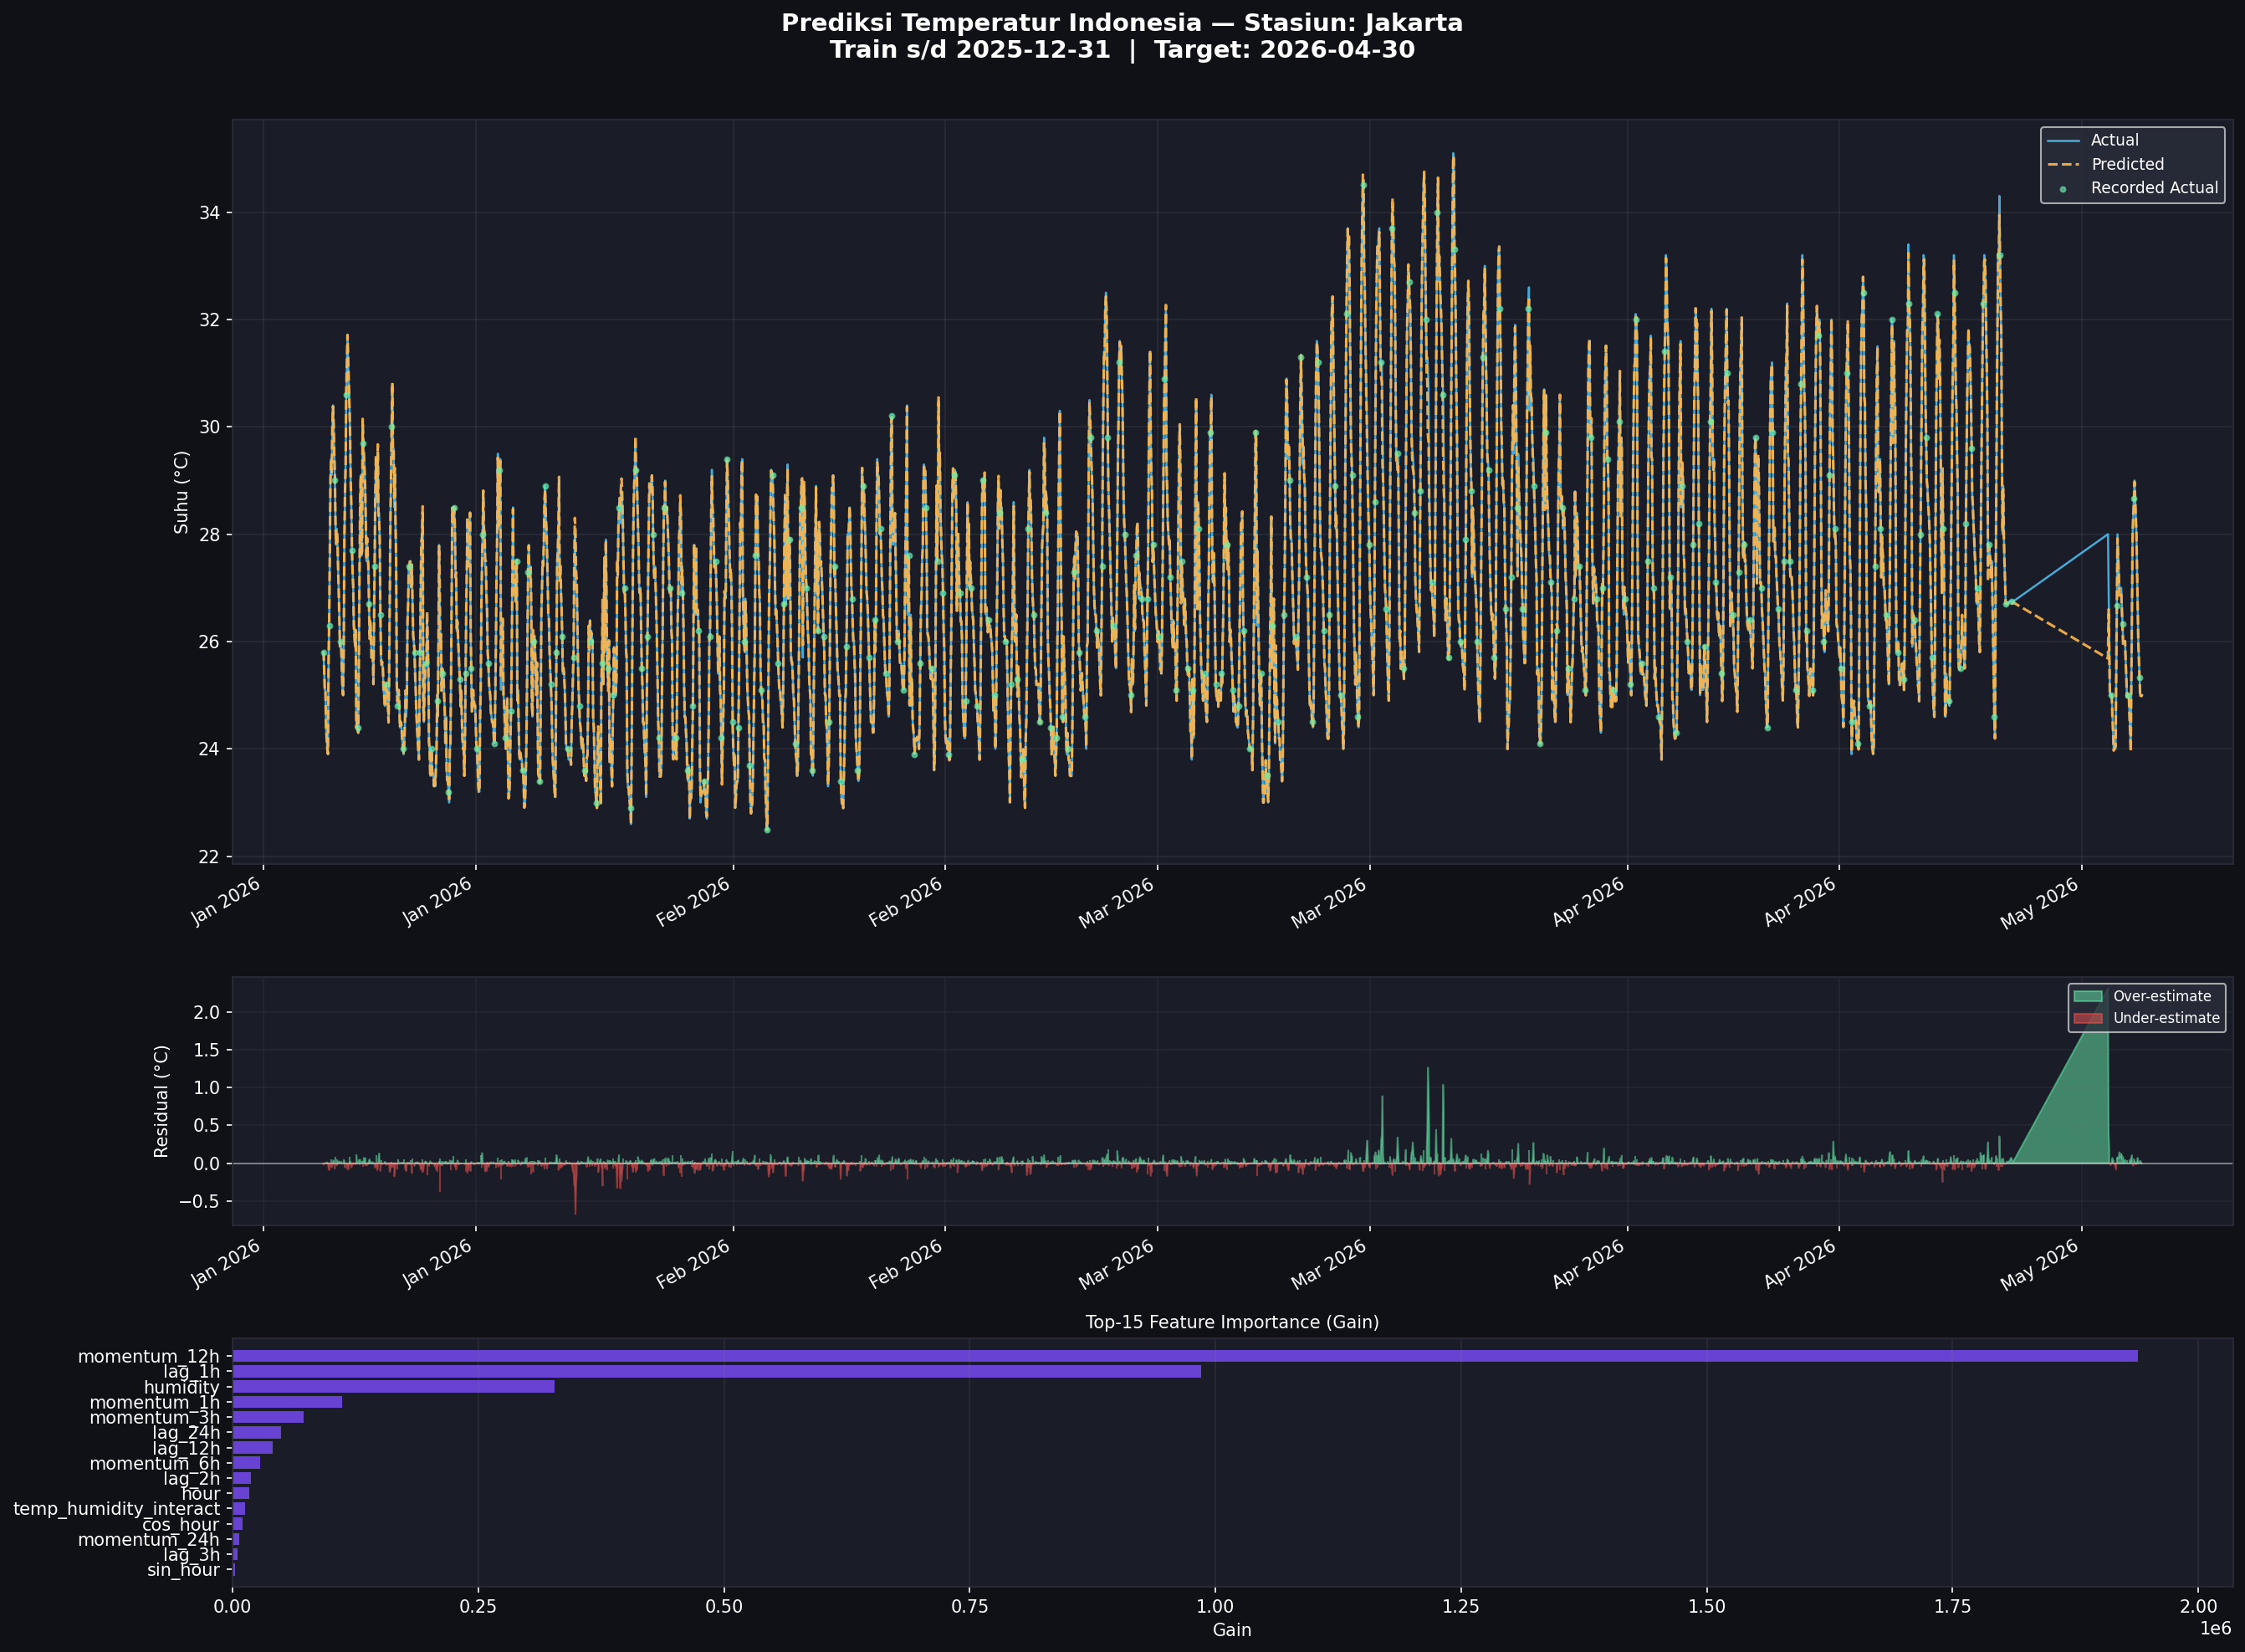

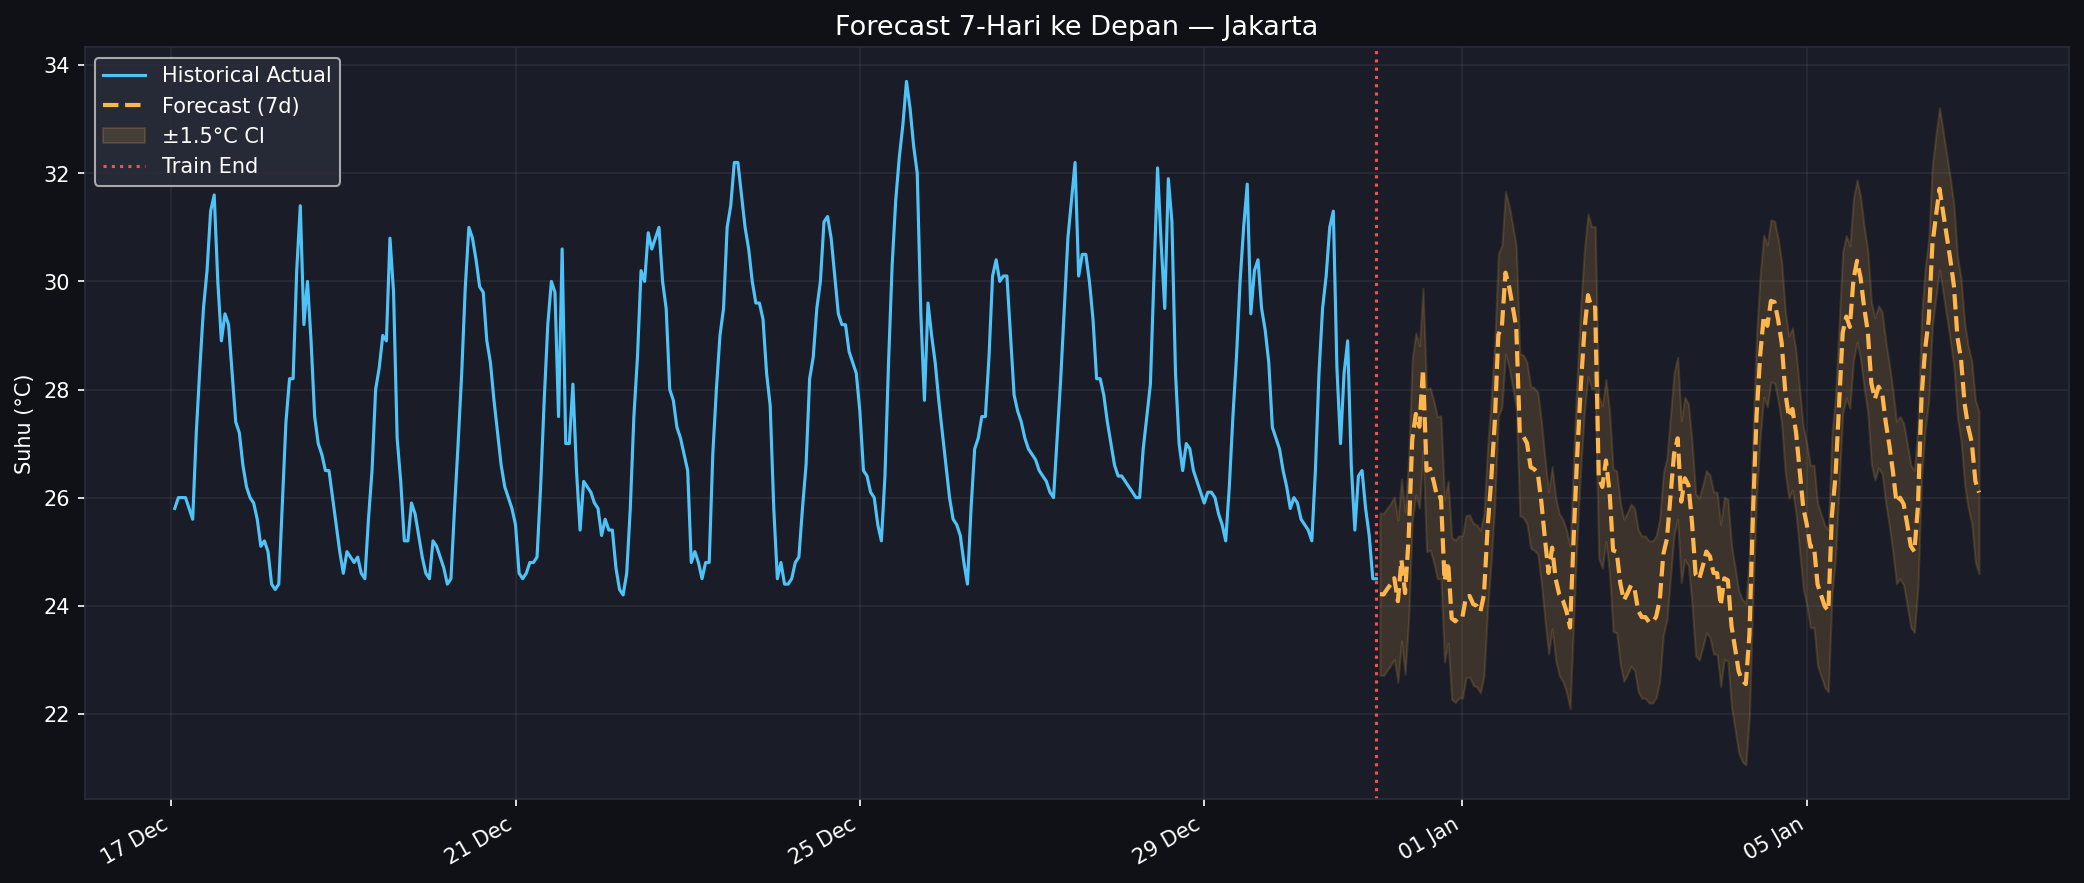

In [20]:
for name, res in results.items():
    mdl        = res["model"]
    df_full    = res["full_pred"]

    # Plot utama (full period)
    img_path   = mdl.plot_results(df_full, last_n_days=120, save=True, show=CONFIG["SHOW_PLOTS"])
    # Plot horizon 7-hari ke depan
    img_horizon= mdl.plot_forecast_horizon(df_full, horizon_days=7, save=True, show=CONFIG["SHOW_PLOTS"])

    print(f"\n📊 Plot untuk {name}:")
    if os.path.exists(img_path):
        display(Image(img_path))
    if os.path.exists(img_horizon):
        display(Image(img_horizon))


## 📋 7. Ringkasan Metrics Semua Stasiun

In [21]:
rows = []
for name, res in results.items():
    m = res["metrics"]
    rows.append({
        "Stasiun":   name,
        "MAE (°C)":  round(m.get("mae",  np.nan), 3),
        "RMSE (°C)": round(m.get("rmse", np.nan), 3),
        "MAPE (%)":  round(m.get("mape", np.nan), 2),
        "R²":        round(m.get("r2",   np.nan), 4),
    })

df_summary = pd.DataFrame(rows)
display(df_summary.style.background_gradient(cmap="RdYlGn", subset=["R²"])
                        .background_gradient(cmap="RdYlGn_r", subset=["MAE (°C)", "RMSE (°C)"]))

# Simpan ringkasan
summary_path = os.path.join(CONFIG["OUTPUT_DIR"], "summary_metrics.csv")
df_summary.to_csv(summary_path, index=False)
print(f"\n💾 Ringkasan disimpan ke: {summary_path}")


AttributeError: The '.style' accessor requires jinja2

## 🔍 8. Analisis Feature Importance

In [ ]:
first_station = CONFIG["STATIONS"][0]
mdl = results[first_station]["model"]

imp_df = pd.DataFrame({
    "feature":    mdl.feature_cols,
    "importance": mdl.model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7), facecolor="#0f1117")
ax.set_facecolor("#1a1d27")
ax.barh(imp_df["feature"], imp_df["importance"], color="#7c4dff", alpha=0.85)
ax.set_title(f"Top-20 Feature Importance (Gain) — {first_station}", color="white", fontsize=13)
ax.set_xlabel("Gain", color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#2a2d3a")
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.15, color="gray")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["OUTPUT_DIR"], f"{first_station.lower()}_feature_importance.png"),
            dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


## 💾 9. Simpan Model

In [ ]:
if CONFIG["SAVE_MODEL"]:
    for name, res in results.items():
        path = res["model"].save_model()
        print(f"  ✓  {name} disimpan → {path}")
else:
    print("SAVE_MODEL=False, model tidak disimpan.")


## 🚀 (Alternatif) Jalankan via Orchestrator Penuh

Sel di bawah menjalankan **seluruh pipeline sekaligus** melalui `main_bmkg_forecast.run_pipeline()`.
Cocok jika ingin menjalankan ulang dengan konfigurasi berbeda tanpa mengulangi sel satu per satu.


In [ ]:
# ─── UNCOMMENT untuk menjalankan pipeline penuh via orchestrator ───────────
# from main_bmkg_forecast import run_pipeline
#
# custom_config = {
#     "END_TRAIN":        "2024-06-30",
#     "TARGET_DATE":      "2024-12-31",
#     "STATIONS":         ["Bandung", "Yogyakarta"],
#     "HISTORICAL_START": "2020-01-01",
#     "FORCE_REFRESH":    False,
#     "SAVE_MODEL":       True,
#     "SHOW_PLOTS":       False,
# }
#
# results_alt = run_pipeline(custom_config)
print("Uncomment kode di atas untuk menjalankan pipeline penuh.")
